In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv(r"C:\Users\HP\OneDrive\Documents\Salary prediction\Salary_Data.csv")
print(df.head())
print(df.info())

   Age  Gender Education Level              Job Title  Years of Experience  \
0   32    Male      Bachelor's      Software Engineer                    5   
1   36  Female      Bachelor's        Sales Associate                    7   
2   29    Male      Bachelor's      Marketing Analyst                    2   
3   31    Male      Bachelor's          Sales Manager                    4   
4   26  Female      Bachelor's  Marketing Coordinator                    1   

   Salary  Salary (bins)  
0   90000          90000  
1   60000          60000  
2   55000          50000  
3   80000          80000  
4   45000          40000  
<class 'pandas.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Age                  373 non-null    int64
 1   Gender               373 non-null    str  
 2   Education Level      373 non-null    str  
 3   Job Title            373 non-nu

In [3]:
df = df[['Age',
         'Gender',
         'Education Level',
         'Job Title',
         'Years of Experience',
         'Salary']]
print(df.isnull().sum())

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [4]:
le_gender = LabelEncoder()

le_education = LabelEncoder()

le_job = LabelEncoder()

df['Gender'] = le_gender.fit_transform(df['Gender'])

df['Education Level'] = le_education.fit_transform(df['Education Level'])

df['Job Title'] = le_job.fit_transform(df['Job Title'])


print(df.head())

   Age  Gender  Education Level  Job Title  Years of Experience  Salary
0   32       1                0        159                    5   90000
1   36       0                0        101                    7   60000
2   29       1                0         81                    2   55000
3   31       1                0        104                    4   80000
4   26       0                0         82                    1   45000


In [5]:
X = df[['Age',
        'Gender',
        'Education Level',
        'Job Title',
        'Years of Experience']]

y = df['Salary']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
y_pred = model.predict(X_test)

In [9]:
print("R2 Score:", r2_score(y_test, y_pred))

print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.9031806546995594
MSE: 272693192.1173954


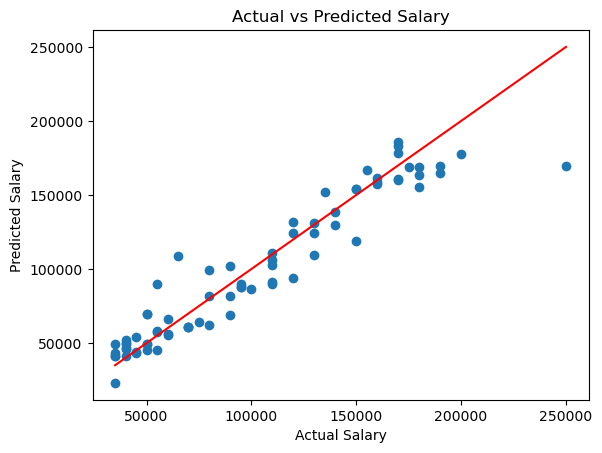

In [10]:
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Salary")

plt.show()

Predict New Data

In [11]:
new_data = pd.DataFrame({
    'Age': [28],
    'Gender': ['Male'],
    'Education Level': ["Bachelor's"],
    'Job Title': ['Software Engineer'],
    'Years of Experience': [3]
})

In [12]:
new_data['Gender'] = le_gender.transform(new_data['Gender'])

new_data['Education Level'] = le_education.transform(
    new_data['Education Level']
)

new_data['Job Title'] = le_job.transform(
    new_data['Job Title']
)

In [13]:
prediction = model.predict(new_data)

print("Predicted Salary:", prediction[0])

Predicted Salary: 52272.88482411079


Predict for all persons

In [14]:
all_predictions = model.predict(X)

In [15]:
df['Predicted Salary'] = model.predict(X)

print(df.head())

   Age  Gender  Education Level  Job Title  Years of Experience  Salary  \
0   32       1                0        159                    5   90000   
1   36       0                0        101                    7   60000   
2   29       1                0         81                    2   55000   
3   31       1                0        104                    4   80000   
4   26       0                0         82                    1   45000   

   Predicted Salary  
0      69169.435649  
1      76069.472332  
2      50108.150851  
3      61929.235465  
4      30577.553460  


In [16]:
df['Predicted Salary'] = model.predict(X)

print(df)

     Age  Gender  Education Level  Job Title  Years of Experience  Salary  \
0     32       1                0        159                    5   90000   
1     36       0                0        101                    7   60000   
2     29       1                0         81                    2   55000   
3     31       1                0        104                    4   80000   
4     26       0                0         82                    1   45000   
..   ...     ...              ...        ...                  ...     ...   
368   44       0                2        115                   16  160000   
369   45       0                2        155                   16  160000   
370   44       0                2        110                   15  150000   
371   44       0                2        114                   16  160000   
372   44       0                2        110                   15  150000   

     Predicted Salary  
0        69169.435649  
1        76069.472332  
2  